# Lecture 8B · Depthwise-separable cost & transfer-learning head

**Goal** · reproduce the compute savings of depthwise-separable convolution and the $1\times1$ bottleneck, then count the *tiny* head you actually train when you freeze a pretrained backbone.

In [1]:
import torch
import torch.nn as nn
torch.manual_seed(0)

def n_params(m):
    return sum(p.numel() for p in m.parameters())

## 1 · Standard vs depthwise-separable convolution

A standard $3\times3$ conv mixes space **and** channels at once. Depthwise-separable splits it into a depthwise (per-channel spatial) conv + a pointwise ($1\times1$) channel-mixing conv.

In [2]:
k, c = 3, 128
standard = k * k * c * c
depthwise = k * k * c
pointwise = c * c
sep = depthwise + pointwise
print(f'standard  3x3, {c}->{c} : {standard:,}          (lecture 147,456)')
print(f'depthwise-separable    : {depthwise:,} + {pointwise:,} = {sep:,}  (lecture 17,536)')
print(f'reduction              : {standard / sep:.1f}x   (lecture ~8.4x)')

standard  3x3, 128->128 : 147,456          (lecture 147,456)
depthwise-separable    : 1,152 + 16,384 = 17,536  (lecture 17,536)
reduction              : 8.4x   (lecture ~8.4x)


In [3]:
# same thing with real PyTorch layers (bias off to match the multiply-add counts)
std = nn.Conv2d(c, c, 3, padding=1, bias=False)
dw  = nn.Conv2d(c, c, 3, padding=1, groups=c, bias=False)   # depthwise: groups = channels
pw  = nn.Conv2d(c, c, 1, bias=False)                        # pointwise 1x1
print('standard params      :', n_params(std))
print('depthwise + pointwise:', n_params(dw), '+', n_params(pw), '=', n_params(dw) + n_params(pw))

standard params      : 147456
depthwise + pointwise: 1152 + 16384 = 17536


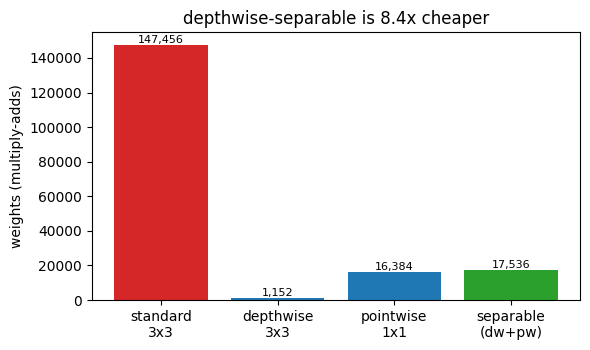

In [4]:
import matplotlib.pyplot as plt
labels = ['standard\n3x3', 'depthwise\n3x3', 'pointwise\n1x1', 'separable\n(dw+pw)']
vals = [standard, depthwise, pointwise, sep]
colors = ['C3', 'C0', 'C0', 'C2']
plt.figure(figsize=(6, 3.6))
bars = plt.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.ylabel('weights (multiply-adds)'); plt.title(f'depthwise-separable is {standard/sep:.1f}x cheaper')
plt.tight_layout(); plt.show()

## 2 · The $1\times1$ bottleneck

A $1\times1$ conv is a per-pixel channel mixer — cheap, and the key to bottlenecks and Inception reductions.

In [5]:
def conv_params(k, c_in, c_out):
    return k * k * c_in * c_out + c_out

print('1x1  256 -> 64 :', conv_params(1, 256, 64), '(lecture 16,448)')
print('3x3  256 -> 64 :', conv_params(3, 256, 64), '(lecture 147,520)')

1x1  256 -> 64 : 16448 (lecture 16,448)
3x3  256 -> 64 : 147520 (lecture 147,520)


## 3 · Transfer learning: freeze the backbone, train a tiny head

We stand in for a pretrained backbone with a small random CNN, **freeze** it, and attach a new classifier head. Only the head gets gradients — that is why transfer learning is safe on small data.

In [6]:
backbone = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(64, 2048), nn.ReLU(),
)
head = nn.Linear(2048, 6)      # new task: 6 classes

for p in backbone.parameters():
    p.requires_grad = False    # FREEZE

total = n_params(backbone) + n_params(head)
trainable = sum(p.numel() for p in list(backbone.parameters()) + list(head.parameters()) if p.requires_grad)
print(f'total params     : {total:,}')
print(f'trainable params : {trainable:,}   (= head only)')
print(f'head 2048->6     : {2048*6+6:,}   (lecture 12,294)')

total params     : 164,806
trainable params : 12,294   (= head only)
head 2048->6     : 12,294   (lecture 12,294)


In [7]:
# one training step touches ONLY the head
x = torch.randn(4, 3, 16, 16)
y = torch.randint(0, 6, (4,))
opt = torch.optim.Adam(head.parameters(), lr=1e-2)
before = backbone[0].weight.clone()
logits = head(backbone(x))
loss = nn.functional.cross_entropy(logits, y)
opt.zero_grad(); loss.backward(); opt.step()
print('loss:', round(loss.item(), 3))
print('backbone weight changed?', not torch.allclose(before, backbone[0].weight))
print('backbone.grad is None    :', backbone[0].weight.grad is None)

loss: 1.793
backbone weight changed? False
backbone.grad is None    : True


## Takeaway

- Depthwise-separable conv cuts cost ~$8\times$ by separating spatial and channel mixing.
- $1\times1$ convs are cheap channel mixers behind bottlenecks and Inception reductions.
- Freezing a backbone means you optimize only a small head — few parameters, big data-efficiency win.